# Notebook 04 – Climate Resilience Investment Framework

## Objective

This notebook develops the **Climate Resilience Investment Priority Framework** for the 32 states of Mexico. Building on the indicator selection, data collection, and exploratory data analysis completed in previous notebooks, this stage integrates the four climate vulnerability dimensions into a single composite index to identify states that should be prioritized for climate resilience investments.

The framework combines four equally weighted dimensions:

- Hazard
- Exposure
- Sensitivity
- Adaptive Capacity

The resulting **Climate Resilience Investment Priority Index (CRIPI)** provides a transparent and reproducible ranking of Mexican states according to their relative climate vulnerability.

To strengthen the robustness of the framework, an unsupervised machine learning approach (K-Means clustering) is subsequently applied to validate and characterize the resulting vulnerability profiles. Rather than determining investment priorities, the clustering analysis serves as a complementary tool for identifying groups of states that share similar vulnerability characteristics and may therefore require different policy interventions.

---

## Framework Workflow

The Climate Resilience Investment Framework is developed through the following stages:

1. Load the normalized analytical dataset.
2. Construct the Composite Climate Resilience Investment Priority Index (CRIPI).
3. Rank the 32 Mexican states according to investment priority.
4. Classify states into investment priority categories.
5. Validate the framework using K-Means clustering.
6. Characterize the resulting vulnerability profiles.
7. Prepare the final dataset for visualization in Tableau.

## 1. Composite Climate Resilience Investment Priority Index (CRIPI)

### Methodology

The Climate Resilience Investment Priority Index (CRIPI) is constructed by aggregating the four Dimension Indices developed during the exploratory analysis:

- Hazard Dimension Index
- Exposure Dimension Index
- Sensitivity Dimension Index
- Adaptive Capacity Dimension Index

Each Dimension Index is normalized to a common scale ranging from 0 to 1, where higher values consistently represent higher climate vulnerability.

Because each dimension represents a distinct and equally important component of climate vulnerability, an equal weighting scheme is adopted. Following the recommendations of the OECD Handbook on Constructing Composite Indicators, equal weighting provides a transparent and objective approach in situations where there is no strong theoretical or empirical justification for assigning different weights.

The composite index is therefore calculated as the arithmetic mean of the four Dimension Indices, assigning a weight of **25%** to each dimension.

Consequently, the CRIPI also ranges from **0 to 1**, where:

- **0** indicates the lowest climate vulnerability and investment priority.
- **1** indicates the highest climate vulnerability and investment priority.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import mapclassify

In [2]:
master_norm = pd.read_csv(
    "../data/processed/climate_resilience_master_norm.csv",
    dtype={"state_code": str}
)

In [3]:
dimension_indices = [
    "hazard_dimension_index",
    "exposure_dimension_index",
    "sensitivity_dimension_index",
    "adaptive_capacity_dimension_index"
]

In [4]:
master_norm["cripi"] = (
    master_norm[dimension_indices]
    .mean(axis=1)
)

In [5]:
master_norm["cripi"] = (
    master_norm[dimension_indices]
    .mean(axis=1)
) * 100

In [6]:
master_norm["cripi"] = master_norm["cripi"].round(2)

In [7]:
master_norm["cripi"].describe()

count    32.000000
mean     34.710000
std      10.870954
min      16.100000
25%      29.377500
50%      33.620000
75%      38.560000
max      56.790000
Name: cripi, dtype: float64

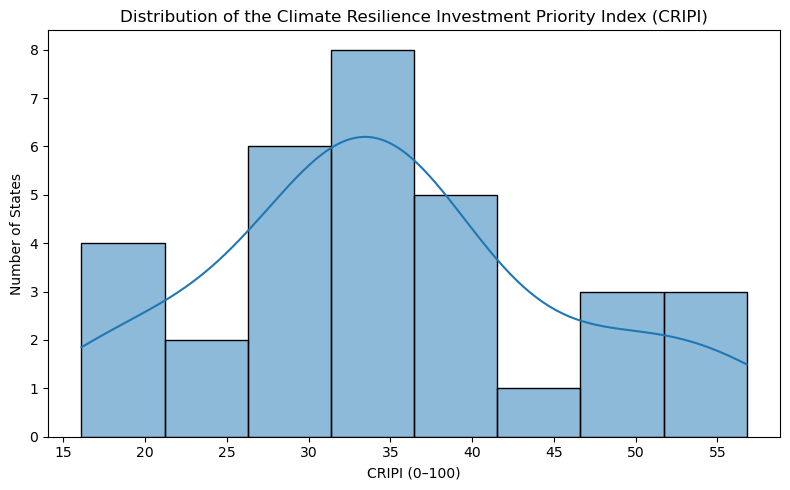

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    master_norm["cripi"],
    bins=8,
    kde=True
)

plt.title("Distribution of the Climate Resilience Investment Priority Index (CRIPI)")

plt.xlabel("CRIPI (0–100)")
plt.ylabel("Number of States")

plt.tight_layout()

plt.show()

In [9]:
ranking = (
    master_norm[
        [
            "state_code",
            "state_name",
            "cripi"
        ]
    ]
    .sort_values(
        by="cripi",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking.index = ranking.index + 1

ranking.head(10)

,state_code,state_name,cripi
1,07,Chiapas,56.79
2,30,Veracruz de Ignacio de la Llave,55.25
3,12,Guerrero,53.25
4,20,Oaxaca,50.98
5,27,Tabasco,49.47
6,04,Campeche,46.86
7,16,Michoacán de Ocampo,43.98
8,18,Nayarit,39.94
9,21,Puebla,38.10
10,31,Yucatán,37.09


In [10]:
ranking = (
    master_norm[
        [
            "state_code",
            "state_name",
            "cripi"
        ]
    ]
    .sort_values(
        by="cripi",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking.insert(
    0,
    "rank",
    range(1, len(ranking) + 1)
)

ranking.head(10)

,rank,state_code,state_name,cripi
0,1,07,Chiapas,56.79
1,2,30,Veracruz de Ignacio de la Llave,55.25
2,3,12,Guerrero,53.25
3,4,20,Oaxaca,50.98
4,5,27,Tabasco,49.47
5,6,04,Campeche,46.86
6,7,16,Michoacán de Ocampo,43.98
7,8,18,Nayarit,39.94
8,9,21,Puebla,38.10
9,10,31,Yucatán,37.09


In [11]:
master_norm = master_norm.merge(
    ranking[["state_code", "rank"]],
    on="state_code",
    how="left"
)

## 2. Investment Priority Categories

To facilitate interpretation and mapping of the Climate Resilience Investment Priority Index (CRIPI), states are grouped into four investment priority categories:

- Low Priority
- Moderate Priority
- High Priority
- Very High Priority

Rather than using arbitrary thresholds or quartiles, the categories are derived using the **Fisher–Jenks optimal classification method**.

Fisher–Jenks identifies class boundaries that minimize variation among observations within the same class while maximizing differences between classes. This makes it particularly suitable for the CRIPI because states with very similar scores are more likely to remain within the same priority category.

The classification is used as a communication and visualization layer, while the continuous CRIPI score and the state ranking remain the primary measures of investment priority.

In [12]:
fj = mapclassify.FisherJenks(
    master_norm["cripi"],
    k=4
)

In [14]:
print("Class breaks:")
print(fj.bins)

print("\nNumber of states per class:")
print(fj.counts)

Class breaks:
[23.61 33.86 43.98 56.79]

Number of states per class:
[ 6 11  9  6]


In [15]:
priority_labels = {
    0: "Low Priority",
    1: "Moderate Priority",
    2: "High Priority",
    3: "Very High Priority"
}

master_norm["investment_priority_category"] = [
    priority_labels[class_id]
    for class_id in fj.yb
]

In [16]:
master_norm[[
        "state_name",
        "cripi",
        "rank",
        "investment_priority_category"]
].sort_values("cripi", ascending=False)

,state_name,cripi,rank,investment_priority_category
6,Chiapas,56.79,1,Very High Priority
29,Veracruz de Ignacio de la Llave,55.25,2,Very High Priority
11,Guerrero,53.25,3,Very High Priority
19,Oaxaca,50.98,4,Very High Priority
26,Tabasco,49.47,5,Very High Priority
3,Campeche,46.86,6,Very High Priority
15,Michoacán de Ocampo,43.98,7,High Priority
17,Nayarit,39.94,8,High Priority
20,Puebla,38.10,9,High Priority
30,Yucatán,37.09,10,High Priority


In [17]:
master_norm["investment_priority_category"].value_counts()

investment_priority_category
Moderate Priority     11
High Priority          9
Very High Priority     6
Low Priority           6
Name: count, dtype: int64

In [18]:
breaks = fj.bins

priority_thresholds = pd.DataFrame({
    "Category": [
        "Low Priority",
        "Moderate Priority",
        "High Priority",
        "Very High Priority"
    ],
    "Upper CRIPI Boundary": breaks
})

priority_thresholds

,Category,Upper CRIPI Boundary
0,Low Priority,23.61
1,Moderate Priority,33.86
2,High Priority,43.98
3,Very High Priority,56.79


In [19]:
priority_thresholds = pd.DataFrame({
    "Investment Priority": [
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    "CRIPI Range": [
        f"≤ {breaks[0]:.2f}",
        f"{breaks[0]:.2f} – {breaks[1]:.2f}",
        f"{breaks[1]:.2f} – {breaks[2]:.2f}",
        f"{breaks[2]:.2f} – {breaks[3]:.2f}"
    ]
})

priority_thresholds

,Investment Priority,CRIPI Range
0,Low,≤ 23.61
1,Moderate,23.61 – 33.86
2,High,33.86 – 43.98
3,Very High,43.98 – 56.79


In [20]:
print("Investment Priority Thresholds")

for category, upper in zip(priority_labels.values(), fj.bins):
    print(f"{category}: {upper:.2f}")

Investment Priority Thresholds
Low Priority: 23.61
Moderate Priority: 33.86
High Priority: 43.98
Very High Priority: 56.79


In [53]:
master_norm["cripi"] = (
    (
        master_norm["hazard_dimension_index"] +
        master_norm["exposure_dimension_index"] +
        master_norm["sensitivity_dimension_index"] +
        master_norm["adaptive_capacity_dimension_index"]
    ) / 4
) * 100

In [54]:
master_norm["rank"] = (
    master_norm["cripi"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

In [55]:
fj = mapclassify.FisherJenks(
    master_norm["cripi"],
    k=4
)

priority_labels = {
    0: "Low Priority",
    1: "Moderate Priority",
    2: "High Priority",
    3: "Very High Priority"
}

master_norm["investment_priority_category"] = (
    pd.Series(fj.yb, index=master_norm.index)
    .map(priority_labels)
)

In [56]:
master_norm.columns

Index(['state_code', 'state_name', 'multidimensional_poverty',
       'primary_sector_employment', 'educational_attainment',
       'access_to_piped_water', 'access_to_drainage',
       'health_service_affiliation', 'population_density',
       'agricultural_land_share', 'flood_hazard', 'cyclone_hazard',
       'drought_hazard', 'marginalization_score', 'hazard_dimension_index',
       'exposure_dimension_index', 'sensitivity_dimension_index',
       'adaptive_capacity_dimension_index', 'cluster', 'cripi', 'rank',
       'investment_priority_category'],
      dtype='object')

## 3. Machine Learning Validation

### K-Means Clustering

To complement the composite Climate Resilience Investment Priority Index (CRIPI), this project applies **K-Means clustering**, an **unsupervised machine learning algorithm**.

Unlike supervised learning algorithms (e.g., Random Forest, Logistic Regression or K-Nearest Neighbors), K-Means does not require predefined target classes. Instead, it automatically groups observations according to their similarity.

In this project, K-Means is not used to predict investment priorities. Instead, it serves as a validation technique by identifying natural groups of Mexican states with similar climate vulnerability profiles based on the four Dimension Indices:

- Hazard Dimension Index
- Exposure Dimension Index
- Sensitivity Dimension Index
- Adaptive Capacity Dimension Index

The resulting clusters provide an independent perspective that complements the composite index and helps assess whether states classified with similar investment priorities also exhibit similar vulnerability characteristics.

In [34]:
master_norm = pd.read_csv(
    "../data/processed/climate_resilience_master_norm.csv",
    dtype={"state_code": str}
)

In [35]:
master_norm.head()

,state_code,state_name,multidimensional_poverty,primary_sector_employment,educational_attainment,access_to_piped_water,access_to_drainage,health_service_affiliation,population_density,agricultural_land_share,flood_hazard,cyclone_hazard,drought_hazard,marginalization_score,hazard_dimension_index,exposure_dimension_index,sensitivity_dimension_index,adaptive_capacity_dimension_index
0,01,Aguascalientes,0.192319,0.120388,0.305405,0.031887,0.023232,0.131044,0.039512,0.575619,0.179104,0.000000,0.128405,0.099518,0.102503,0.307566,0.137409,0.122892
1,02,Baja California,0.000773,0.148220,0.345946,0.073694,0.177594,0.328513,0.006826,0.206812,0.380597,0.123116,1.000000,0.165329,0.501238,0.106819,0.104774,0.231437
2,03,Baja California Sur,0.000000,0.192233,0.308108,0.261825,0.146618,0.052869,0.000000,0.000000,0.000000,1.000000,0.509728,0.158106,0.503243,0.000000,0.116780,0.192355
3,04,Campeche,0.588441,0.505825,0.500000,0.573605,0.274135,0.308631,0.000861,0.573827,0.921642,0.532663,0.517510,0.452648,0.657272,0.287344,0.515638,0.414093
4,05,Coahuila de Zaragoza,0.090935,0.081877,0.283784,0.080779,0.061435,0.163127,0.001625,0.388201,0.231343,0.045226,0.501946,0.072231,0.259505,0.194913,0.081681,0.147281


In [36]:
dimension_indices = [
    "hazard_dimension_index",
    "exposure_dimension_index",
    "sensitivity_dimension_index",
    "adaptive_capacity_dimension_index"
]

X_cluster = master_norm[dimension_indices].copy()

In [37]:
X_cluster.describe()

,hazard_dimension_index,exposure_dimension_index,sensitivity_dimension_index,adaptive_capacity_dimension_index
count,32.000000,32.000000,32.000000,32.000000
mean,0.379926,0.286500,0.362237,0.359745
std,0.179995,0.125680,0.239500,0.193185
min,0.068921,0.000000,0.026433,0.101155
25%,0.240404,0.201257,0.184664,0.204905
50%,0.389556,0.271573,0.339225,0.334127
75%,0.501694,0.357856,0.491447,0.435220
max,0.737875,0.652705,0.972980,0.885748


### 3.1 Selecting the Number of Clusters

Choosing the appropriate number of clusters (K) is an important step in K-Means.

Two complementary evaluation methods are used:

- **Elbow Method**, which evaluates how compact the clusters are.
- **Silhouette Score**, which evaluates how well-separated the clusters are.

Using both methods provides a more robust basis for selecting the optimal number of clusters.

#### 3.1.1 Elbow Method

In [38]:
inertia = []

k_values = range(2,11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)

    inertia.append(kmeans.inertia_)

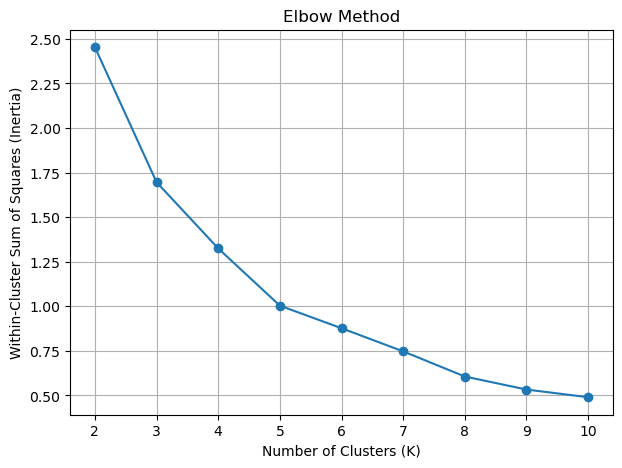

In [39]:
plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Within-Cluster Sum of Squares (Inertia)")

plt.grid(True)

plt.show()

#### 3.1.2 Silhouette Score

In [40]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    silhouette_scores.append(
        silhouette_score(
            X_cluster,
            labels
        )
    )

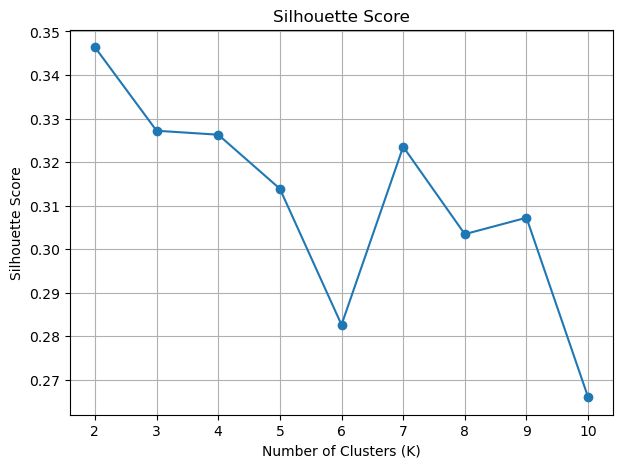

In [41]:
plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

#### 3.1.3 Comparing both methods

In [42]:
cluster_selection = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

cluster_selection

,K,Inertia,Silhouette Score
0,2,2.453124,0.346370
1,3,1.695950,0.327199
2,4,1.324683,0.326288
3,5,1.003708,0.313883
4,6,0.877153,0.282655
5,7,0.747353,0.323529
6,8,0.606423,0.303462
7,9,0.533340,0.307235
8,10,0.490254,0.266029


#### 3.1.4 Selection of the Optimal Number of Clusters

The Elbow Method did not reveal a single, clearly defined inflection point, although the reduction in within-cluster variation began to stabilize around four to five clusters.

The Silhouette Score reached its highest value at K = 2; however, the scores for K = 3 and K = 4 were only marginally lower (0.327 and 0.326, respectively), indicating that these solutions also provide acceptable cluster separation.

Given the objective of identifying meaningful climate vulnerability profiles rather than simply dividing states into two broad groups, a **four-cluster solution was selected**. This choice provides a balance between statistical performance, interpretability, and practical usefulness for climate resilience planning and investment prioritization.

An alternative five-cluster solution was also evaluated as a robustness check. While it divided one intermediate cluster into two smaller groups, it did not reveal additional vulnerability profiles or improve the overall interpretability of the results. Given the slightly higher Silhouette Score and the more parsimonious segmentation, the four-cluster solution was retained.

In [43]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

master_norm["cluster"] = kmeans.fit_predict(X_cluster)

In [44]:
master_norm["cluster"].value_counts().sort_index()

cluster
0     3
1    14
2     7
3     8
Name: count, dtype: int64

In [45]:
cluster_states = (
    master_norm[
        ["state_name", "cluster"]
    ]
    .sort_values(
        ["cluster", "state_name"]
    )
)

cluster_states

,state_name,cluster
6,Chiapas,0
11,Guerrero,0
19,Oaxaca,0
0,Aguascalientes,1
1,Baja California,1
2,Baja California Sur,1
7,Chihuahua,1
8,Ciudad de México,1
4,Coahuila de Zaragoza,1
5,Colima,1


### 3.2 Cluster Profiles
To interpret the clusters, the average value of each Dimension Index is calculated for every cluster.

These average values (cluster centroids) describe the typical vulnerability profile of each group of states and help identify the main characteristics that distinguish the clusters.

In [46]:
cluster_profiles = (
    master_norm
    .groupby("cluster")[dimension_indices]
    .mean()
    .round(2)
)

cluster_profiles

,hazard_dimension_index,exposure_dimension_index,sensitivity_dimension_index,adaptive_capacity_dimension_index
cluster,,,,
0,0.22,0.26,0.89,0.78
1,0.45,0.27,0.15,0.19
2,0.19,0.27,0.45,0.42
3,0.48,0.35,0.45,0.44


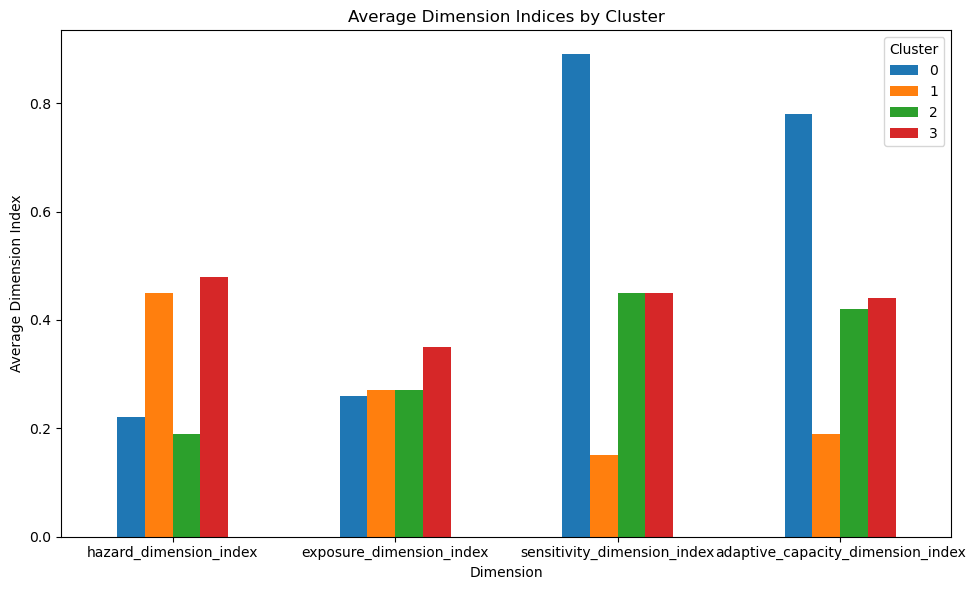

In [47]:
cluster_profiles.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Dimension Indices by Cluster")

plt.ylabel("Average Dimension Index")

plt.xlabel("Dimension")

plt.xticks(rotation=0)

plt.legend(title="Cluster")

plt.tight_layout()

plt.show()

### 3.3 Comparing Clusters and Investment Priority Categories

The final step compares the K-Means clusters with the investment priority categories derived from the Climate Resilience Investment Priority Index (CRIPI).

Although both approaches classify the states differently, a strong correspondence between clusters and priority categories would provide additional support for the robustness of the proposed framework.

In [57]:
cluster_vs_priority = pd.crosstab(
    master_norm["cluster"],
    master_norm["investment_priority_category"]
)

cluster_vs_priority

investment_priority_category,High Priority,Low Priority,Moderate Priority,Very High Priority
cluster,,,,
0,0,0,0,3
1,2,6,6,0
2,2,0,5,0
3,5,0,0,3


In [58]:
cluster_vs_priority_pct = (
    pd.crosstab(
        master_norm["cluster"],
        master_norm["investment_priority_category"],
        normalize="index"
    ) * 100
).round(1)

cluster_vs_priority_pct

investment_priority_category,High Priority,Low Priority,Moderate Priority,Very High Priority
cluster,,,,
0,0.0,0.0,0.0,100.0
1,14.3,42.9,42.9,0.0
2,28.6,0.0,71.4,0.0
3,62.5,0.0,0.0,37.5


In [59]:
cluster_members = (
    master_norm[
        [
            "state_name",
            "cluster",
            "cripi",
            "investment_priority_category"
        ]
    ]
    .sort_values(
        ["cluster", "cripi"],
        ascending=[True, False]
    )
)

cluster_members

,state_name,cluster,cripi,investment_priority_category
6,Chiapas,0,56.794058,Very High Priority
11,Guerrero,0,53.248661,Very High Priority
19,Oaxaca,0,50.976991,Very High Priority
27,Tamaulipas,1,36.632365,High Priority
24,Sinaloa,1,36.494135,High Priority
8,Ciudad de México,1,33.377311,Moderate Priority
22,Quintana Roo,1,32.281242,Moderate Priority
13,Jalisco,1,31.232821,Moderate Priority
25,Sonora,1,29.839055,Moderate Priority
5,Colima,1,29.490523,Moderate Priority


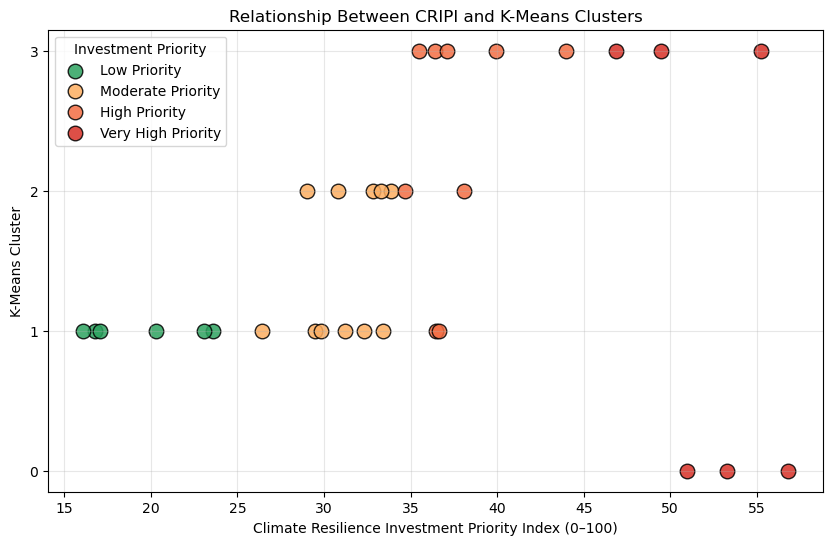

In [63]:
priority_colors = {
    "Low Priority": "#2ca25f",
    "Moderate Priority": "#fdae61",
    "High Priority": "#f46d43",
    "Very High Priority": "#d73027"
}

plt.figure(figsize=(10,6))

for category in priority_colors:

    subset = master_norm[
        master_norm["investment_priority_category"] == category
    ]

    plt.scatter(
        subset["cripi"],
        subset["cluster"],
        s=110,
        alpha=0.85,
        edgecolor="black",
        color=priority_colors[category],
        label=category
    )

plt.xlabel("Climate Resilience Investment Priority Index (0–100)")
plt.ylabel("K-Means Cluster")
plt.title("Relationship Between CRIPI and K-Means Clusters")

plt.yticks([0,1,2,3])

plt.grid(alpha=0.3)

plt.legend(title="Investment Priority")

plt.show()

Interpretation:
The K-Means clustering results generally support the proposed Climate Resilience Investment Priority Framework.

The clustering algorithm successfully identified distinct vulnerability profiles across the Mexican states. The most socially vulnerable states (Chiapas, Guerrero and Oaxaca) formed a separate cluster, while another cluster grouped states characterized by high hazard exposure combined with elevated socioeconomic vulnerability.

Although one cluster contains a mixture of Low and Moderate Priority states, this reflects the continuous nature of climate vulnerability rather than a limitation of the framework. Unlike the composite index, which produces a continuous investment priority score, K-Means groups observations solely according to similarity in their multidimensional characteristics.

Overall, the clustering analysis provides an independent validation of the proposed framework and demonstrates that the Climate Resilience Investment Priority Index captures meaningful differences in vulnerability across Mexican states.

In [64]:
master_norm.to_csv(
    "../data/processed/climate_resilience_master_norm.csv",
    index=False
)

In [66]:
dashboard = pd.read_csv(
    "../data/processed/climate_resilience_master.csv",
    dtype={"state_code": str}
)

In [67]:
dashboard["Climate_Resilience_Investment_Priority_Index"] = master_norm["cripi"]

dashboard["Rank"] = master_norm["rank"]

dashboard["Investment_Priority_Category"] = master_norm["investment_priority_category"]

dashboard["Hazard_Dimension_Index"] = master_norm["hazard_dimension_index"] * 100

dashboard["Exposure_Dimension_Index"] = master_norm["exposure_dimension_index"] * 100

dashboard["Sensitivity_Dimension_Index"] = master_norm["sensitivity_dimension_index"] * 100

dashboard["Adaptive_Capacity_Dimension_Index"] = (
    master_norm["adaptive_capacity_dimension_index"] * 100
)

dashboard["Cluster"] = master_norm["cluster"]

In [68]:
cluster_mapping = {
    0: 1,
    1: 2,
    2: 3,
    3: 4
}

master_norm["cluster"] = (
    master_norm["cluster"]
    .map(cluster_mapping)
)

In [69]:
dashboard["Cluster"] = master_norm["cluster"]

In [71]:
dashboard.columns

Index(['state_code', 'state_name', 'multidimensional_poverty',
       'primary_sector_employment', 'educational_attainment',
       'access_to_piped_water', 'access_to_drainage',
       'health_service_affiliation', 'population_density',
       'agricultural_land_share', 'flood_hazard', 'cyclone_hazard',
       'drought_hazard', 'marginalization_score',
       'Climate_Resilience_Investment_Priority_Index', 'Rank',
       'Investment_Priority_Category', 'Hazard_Dimension_Index',
       'Exposure_Dimension_Index', 'Sensitivity_Dimension_Index',
       'Adaptive_Capacity_Dimension_Index', 'Cluster'],
      dtype='object')

In [73]:
dashboard = dashboard.rename(columns={

    # Geographic information
    "state_code": "State Code",
    "state_name": "State",

    # Framework outputs
    "Climate_Resilience_Investment_Priority_Index":
        "Climate Resilience Investment Priority Index (0–100)",

    "Rank":
        "Investment Priority Rank",

    "Investment_Priority_Category":
        "Investment Priority Category",

    "Cluster":
        "Cluster",

    "Hazard_Dimension_Index":
        "Hazard Dimension Index (0–100)",

    "Exposure_Dimension_Index":
        "Exposure Dimension Index (0–100)",

    "Sensitivity_Dimension_Index":
        "Sensitivity Dimension Index (0–100)",

    "Adaptive_Capacity_Dimension_Index":
        "Adaptive Capacity Dimension Index (0–100)",

    # Hazard
    "flood_hazard":
        "Flood Hazard Index (1–5 scale)",

    "cyclone_hazard":
        "Cyclone Hazard Index (1–5 scale)",

    "drought_hazard":
        "Drought Hazard Index (1–5 scale)",

    # Exposure
    "population_density":
        "Population Density (inhabitants/km²)",

    "agricultural_land_share":
        "Agricultural Land Share (% of state area)",

    # Sensitivity
    "multidimensional_poverty":
        "Multidimensional Poverty (% of population)",

    "marginalization_score":
        "Marginalization Score",

    "primary_sector_employment":
        "Employment in Primary Sector (% of employment)",

    # Adaptive Capacity
    "educational_attainment":
        "Educational Attainment (avg years, age 15+)",

    "access_to_piped_water":
        "Access to Piped Water (% of households)",

    "access_to_drainage":
        "Access to Drainage (% of households)",

    "health_service_affiliation":
        "Health Service Affiliation (% of population)"
})

In [74]:
dashboard = dashboard[[
    # Geographic information
    "State Code",
    "State",

    # Framework outputs
    "Climate Resilience Investment Priority Index (0–100)",
    "Investment Priority Rank",
    "Investment Priority Category",
    "Cluster",

    "Hazard Dimension Index (0–100)",
    "Exposure Dimension Index (0–100)",
    "Sensitivity Dimension Index (0–100)",
    "Adaptive Capacity Dimension Index (0–100)",

    # Hazard
    "Flood Hazard Index (1–5 scale)",
    "Cyclone Hazard Index (1–5 scale)",
    "Drought Hazard Index (1–5 scale)",

    # Exposure
    "Population Density (inhabitants/km²)",
    "Agricultural Land Share (% of state area)",

    # Sensitivity
    "Multidimensional Poverty (% of population)",
    "Marginalization Score",
    "Employment in Primary Sector (% of employment)",

    # Adaptive Capacity
    "Educational Attainment (average years of schooling, age 15+)",
    "Access to Piped Water (% of households)",
    "Access to Drainage (% of households)",
    "Health Service Affiliation (% of population)"
]]

In [80]:
dashboard.head()

,State Code,State,Climate Resilience Investment Priority Index (0–100),Investment Priority Rank,Investment Priority Category,Cluster,Hazard Dimension Index (0–100),Exposure Dimension Index (0–100),Sensitivity Dimension Index (0–100),Adaptive Capacity Dimension Index (0–100),...,Drought Hazard Index (1–5 scale),Population Density (inhabitants/km²),Agricultural Land Share (% of state area),Multidimensional Poverty (% of population),Marginalization Score,Employment in Primary Sector (% of employment),"Educational Attainment (average years of schooling, age 15+)",Access to Piped Water (% of households),Access to Drainage (% of households),Health Service Affiliation (% of population)
0,01,Aguascalientes,16.8,31,Low Priority,2,10.3,30.8,13.7,12.3,...,2.00,253.9,55.86,23.722320,1.24,4.17,10.35,95.27,99.26,81.45
1,02,Baja California,23.6,27,Low Priority,2,50.1,10.7,10.5,23.1,...,4.24,52.8,33.23,13.370820,2.06,5.03,10.20,92.91,96.27,77.08
2,03,Baja California Sur,20.3,29,Low Priority,2,50.3,0.0,11.7,19.2,...,2.98,10.8,20.54,13.329031,1.97,6.39,10.34,82.29,96.87,83.18
3,04,Campeche,46.9,6,Very High Priority,4,65.7,28.7,51.6,41.4,...,3.00,16.1,55.75,45.129444,5.64,16.08,9.63,64.69,94.40,77.52
4,05,Coahuila de Zaragoza,17.1,30,Low Priority,2,26.0,19.5,8.2,14.7,...,2.96,20.8,44.36,18.243322,0.90,2.98,10.43,92.51,98.52,80.74


In [81]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

dashboard.head()

,State Code,State,Climate Resilience Investment Priority Index (0–100),Investment Priority Rank,Investment Priority Category,Cluster,Hazard Dimension Index (0–100),Exposure Dimension Index (0–100),Sensitivity Dimension Index (0–100),Adaptive Capacity Dimension Index (0–100),Flood Hazard Index (1–5 scale),Cyclone Hazard Index (1–5 scale),Drought Hazard Index (1–5 scale),Population Density (inhabitants/km²),Agricultural Land Share (% of state area),Multidimensional Poverty (% of population),Marginalization Score,Employment in Primary Sector (% of employment),"Educational Attainment (average years of schooling, age 15+)",Access to Piped Water (% of households),Access to Drainage (% of households),Health Service Affiliation (% of population)
0,01,Aguascalientes,16.8,31,Low Priority,2,10.3,30.8,13.7,12.3,2.80,1.00,2.00,253.9,55.86,23.722320,1.24,4.17,10.35,95.27,99.26,81.45
1,02,Baja California,23.6,27,Low Priority,2,50.1,10.7,10.5,23.1,3.34,1.49,4.24,52.8,33.23,13.370820,2.06,5.03,10.20,92.91,96.27,77.08
2,03,Baja California Sur,20.3,29,Low Priority,2,50.3,0.0,11.7,19.2,2.32,4.98,2.98,10.8,20.54,13.329031,1.97,6.39,10.34,82.29,96.87,83.18
3,04,Campeche,46.9,6,Very High Priority,4,65.7,28.7,51.6,41.4,4.79,3.12,3.00,16.1,55.75,45.129444,5.64,16.08,9.63,64.69,94.40,77.52
4,05,Coahuila de Zaragoza,17.1,30,Low Priority,2,26.0,19.5,8.2,14.7,2.94,1.18,2.96,20.8,44.36,18.243322,0.90,2.98,10.43,92.51,98.52,80.74


In [79]:
dashboard["Climate Resilience Investment Priority Index (0–100)"] = (
    dashboard["Climate Resilience Investment Priority Index (0–100)"].round(1)
)

dashboard["Hazard Dimension Index (0–100)"] = (
    dashboard["Hazard Dimension Index (0–100)"].round(1)
)

dashboard["Exposure Dimension Index (0–100)"] = (
    dashboard["Exposure Dimension Index (0–100)"].round(1)
)

dashboard["Sensitivity Dimension Index (0–100)"] = (
    dashboard["Sensitivity Dimension Index (0–100)"].round(1)
)

dashboard["Adaptive Capacity Dimension Index (0–100)"] = (
    dashboard["Adaptive Capacity Dimension Index (0–100)"].round(1))

In [82]:
round_1 = [
    "Climate Resilience Investment Priority Index (0–100)",
    "Hazard Dimension Index (0–100)",
    "Exposure Dimension Index (0–100)",
    "Sensitivity Dimension Index (0–100)",
    "Adaptive Capacity Dimension Index (0–100)",
    "Population Density (inhabitants/km²)",
    "Agricultural Land Share (% of state area)",
    "Multidimensional Poverty (% of population)",
    "Employment in Primary Sector (% of employment)",
    "Educational Attainment (average years of schooling, age 15+)",
    "Access to Piped Water (% of households)",
    "Access to Drainage (% of households)",
    "Health Service Affiliation (% of population)"
]

dashboard[round_1] = dashboard[round_1].round(1)

# Variables rounded to 2 decimals
round_2 = [
    "Marginalization Score",
    "Flood Hazard Index (1–5 scale)",
    "Cyclone Hazard Index (1–5 scale)",
    "Drought Hazard Index (1–5 scale)"
]

dashboard[round_2] = dashboard[round_2].round(2)

In [83]:
dashboard.to_csv(
    "../data/processed/climate_resilience_dashboard.csv",
    index=False,
    encoding="utf-8-sig"
)